In [1]:
from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
from matplotlib import pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    f1_score,
)

from estuary.util.img import false_color

In [2]:
SAVE_DIR = Path("/Users/kyledorman/data/estuary/display/paper_figures")
SAVE_DIR.mkdir(exist_ok=True, parents=True)

In [3]:
def inspect_row(iii, suffix_t, suffix_p):
    _, row = next(iii)

    with rasterio.open(row[f"source_tif{suffix_t}"]) as src:
        data = src.read()
        nodata = src.read(1, masked=True).mask
        t = false_color(data, nodata)

    with rasterio.open(row[f"source_tif{suffix_p}"]) as src:
        data = src.read()
        nodata = src.read(1, masked=True).mask
        p = false_color(data, nodata)

    label_t = row[f"label{suffix_t}"]
    label_p = row[f"label{suffix_p}"]

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].set_title(f"Region {row.region} True Label: {label_t}")
    axes[1].set_title(f"Pred Label: {label_p}")

    axes[0].imshow(t)
    axes[0].axis("off")
    axes[1].imshow(p)
    axes[1].axis("off")

    fig.tight_layout()
    plt.show()

In [4]:
BASE = Path("/Volumes/x10pro/estuary/")

In [5]:
gdf = gpd.read_file(BASE / "geos/ca_data_w_empa_pmep_usgs.geojson")
gdf = gdf[~gdf.skipped].copy()
gdf = gdf.set_index("Site code")
gdf.head(3)

,Site name,skipped,PMEP_EstuaryID,Estuary_Name,Data_Source,CMECS_Class,PMEP_Region,System_Order,Estuary_Hectares,Link,...,siteid,point_geom_lat,point_geom_long,pmep_pt_geom_lat,pmep_pt_geom_long,usgs_station_nm,usgs_site_no,usgs_site_latitude,usgs_site_longitude,geometry
Site code,,,,,,,,,,,,,,,,,,,,,
11,Los Penasquitos Lagoon,False,4056.0,Los Penasquitos Lagoon,PMEP,Lagoonal Estuary,Southern California Bight,299.0,95.475975,4056_Los Penasquitos Lagoon,...,SC-LPL,32.933,-117.260,32.931536,-117.256714,None,None,None,None,"POLYGON ((-117.25816 32.93218, -117.25817 32.9..."
18,Zuma Lagoon,False,4018.0,Zuma Canyon,PMEP,Lagoonal Estuary,Southern California Bight,262.0,1.779315,4018_Zuma Canyon,...,SC-ZUM,34.015,-118.821,34.014565,-118.820618,None,None,None,None,"POLYGON ((-118.81685 34.01177, -118.81699 34.0..."
21,Ventura River,False,4010.0,Ventura River,PMEP,Lagoonal Estuary,Southern California Bight,253.0,17.225009,4010_Ventura River,...,SC-VEN,34.276,-119.308,34.277309,-119.308329,None,None,None,None,"POLYGON ((-119.30473 34.27203, -119.3049 34.27..."


In [6]:
ss_df = pd.read_csv("/Volumes/x10pro/estuary/labeling/skysat/labels.csv")
ss_df = ss_df[ss_df.region.isin(gdf.index)].copy()
ss_df = ss_df[ss_df.label != "unsure"].copy()
ss_df["acquired"] = pd.to_datetime(ss_df["acquired"], errors="coerce", utc=True)

ssw_df = pd.read_csv("/Volumes/x10pro/estuary/labeling/skysat_water/labels.csv")
ssw_df = ssw_df[ssw_df.region.isin(gdf.index)].copy()
ssw_df = ssw_df[ssw_df.label != "unsure"].copy()
ssw_df["acquired"] = pd.to_datetime(ssw_df["acquired"], errors="coerce", utc=True)

ss_df.head()

,region,source_tif,label,acquired,instrument,year,month,asset_id
0,11,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2024-10-20 17:07:34+00:00,skysat,2024,10,20241020_170734_ssc13_u0001
1,11,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2024-10-21 16:24:30+00:00,skysat,2024,10,20241021_162430_ssc4_u0001
2,14,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2024-10-22 17:19:42+00:00,skysat,2024,10,20241022_171942_ssc1_u0001
3,15,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2024-10-22 17:19:42+00:00,skysat,2024,10,20241022_171942_ssc1_u0001
4,16,/Volumes/x10pro/estuary/sat_data/skysat/result...,closed,2024-10-22 17:19:42+00:00,skysat,2024,10,20241022_171942_ssc1_u0001


In [7]:
d_df = pd.read_csv("/Volumes/x10pro/estuary/labeling/dove_split_by_region/labels.csv")
d_df = d_df[d_df.region.isin(gdf.index)].copy()
d_df = d_df[d_df.label != "unsure"].copy()
d_df["acquired"] = pd.to_datetime(d_df["acquired"], errors="coerce", utc=True)

dw_df = pd.read_csv("/Volumes/x10pro/estuary/labeling/dove_water/labels.csv")
dw_df = dw_df[dw_df.region.isin(gdf.index)].copy()
dw_df = dw_df[dw_df.label != "unsure"].copy()
dw_df["acquired"] = pd.to_datetime(dw_df["acquired"], errors="coerce", utc=True)

d_df.head()

,region,source_tif,label,acquired,instrument,year,month,asset_id
0,22,/Volumes/x10pro/estuary/sat_data/dove/results/...,open,2017-01-28 17:55:35+00:00,dove,2017,1,20170128_175535_0e26
1,22,/Volumes/x10pro/estuary/sat_data/dove/results/...,perched open,2017-02-13 17:57:19+00:00,dove,2017,2,20170213_175719_0e0f
2,22,/Volumes/x10pro/estuary/sat_data/dove/results/...,closed,2017-04-15 17:50:47+00:00,dove,2017,4,20170415_175047_1009
3,22,/Volumes/x10pro/estuary/sat_data/dove/results/...,closed,2017-05-08 17:52:59+00:00,dove,2017,5,20170508_175259_0f25
4,22,/Volumes/x10pro/estuary/sat_data/dove/results/...,closed,2017-06-14 17:54:49+00:00,dove,2017,6,20170614_175449_0f52


In [8]:
ss_pairs = pd.merge(
    ss_df, ssw_df, on=["region", "asset_id"], how="inner", suffixes=("_img", "_water")
)
dd_pairs = pd.merge(
    d_df, dw_df, on=["region", "asset_id"], how="inner", suffixes=("_img", "_water")
)

a = ss_df.sort_values("acquired").reset_index(drop=True)
b = d_df.sort_values("acquired").reset_index(drop=True)

# cross-join within region, then filter by window
tmp = pd.merge(
    a,
    b[["source_tif", "asset_id", "region", "label", "acquired"]],
    on="region",
    suffixes=("_ss", "_dd"),
)
tol = pd.Timedelta("10h")
tmp["time_diff"] = (tmp["acquired_dd"] - tmp["acquired_ss"]).abs()
mask = tmp["time_diff"] < tol
d_ss_pairs = tmp.loc[mask].sort_values(["region", "asset_id_ss", "asset_id_dd"])
d_ss_pairs = d_ss_pairs.drop_duplicates(["region", "asset_id_ss"])

len(d_ss_pairs)

477

In [9]:
d_ss_pairs.head()

,region,source_tif_ss,label_ss,acquired_ss,instrument,year,month,asset_id_ss,source_tif_dd,asset_id_dd,label_dd,acquired_dd,time_diff
30474,11,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2020-08-01 18:45:36+00:00,skysat,2020,8,20200801_184536_ssc1_u0002,/Volumes/x10pro/estuary/sat_data/dove/results/...,20200801_161237_0f2e,open,2020-08-01 16:12:37+00:00,0 days 02:32:59
55911,11,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2021-11-10 21:35:51+00:00,skysat,2021,11,20211110_213551_ssc6_u0001,/Volumes/x10pro/estuary/sat_data/superdove/res...,20211110_175344_57_227e,open,2021-11-10 17:53:44+00:00,0 days 03:42:07
72891,11,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2022-06-24 01:30:52+00:00,skysat,2022,6,20220624_013052_ssc18_u0001,/Volumes/x10pro/estuary/sat_data/superdove/res...,20220623_180838_89_2478,open,2022-06-23 18:08:38+00:00,0 days 07:22:14
100710,11,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2023-06-29 21:52:17+00:00,skysat,2023,6,20230629_215217_ssc6_u0001,/Volumes/x10pro/estuary/sat_data/superdove/res...,20230629_173907_70_24c3,open,2023-06-29 17:39:07+00:00,0 days 04:13:10
58893,14,/Volumes/x10pro/estuary/sat_data/skysat/result...,closed,2021-12-15 18:44:53+00:00,skysat,2021,12,20211215_184453_ssc1_u0001,/Volumes/x10pro/estuary/sat_data/superdove/res...,20211215_182546_45_2424,closed,2021-12-15 18:25:46+00:00,0 days 00:19:07


In [10]:
d_ss_pairs.label_ss.value_counts()

label_ss
closed          233
open            203
perched open     41
Name: count, dtype: int64

Accuracy 3 class 77.6
Perched F1 44.2


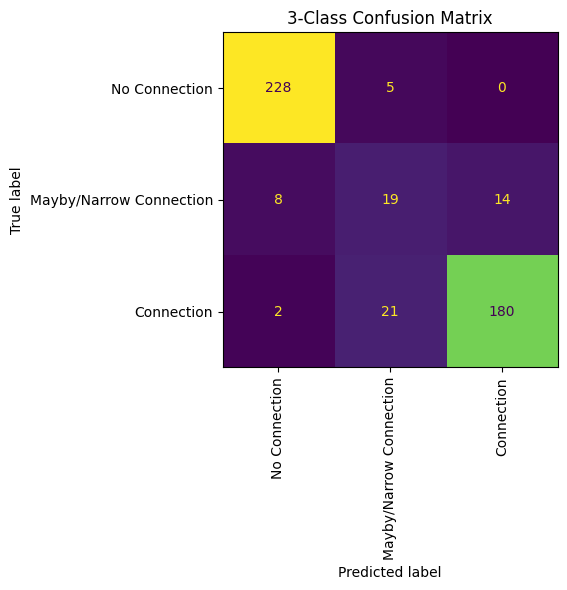

Accuracy Open/Closed 96.9


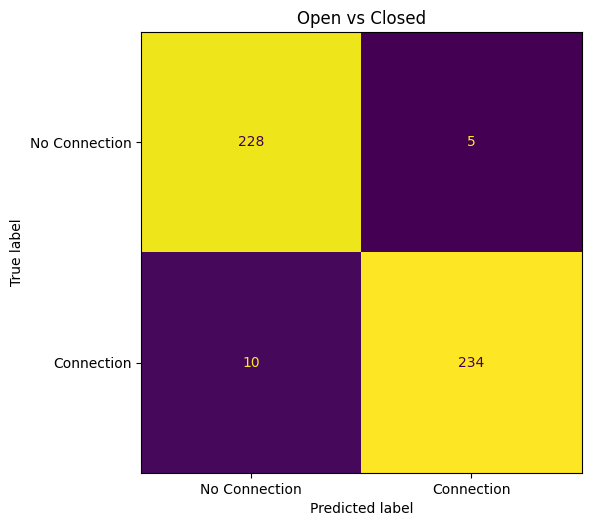

Accuracy No Perch 99.5


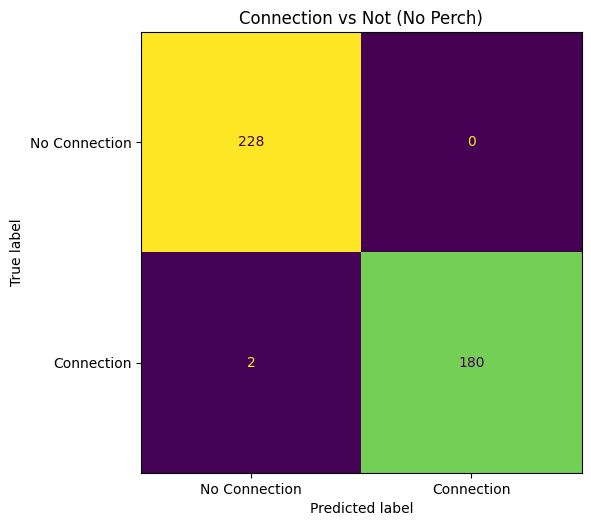

In [11]:
labels = ["closed", "perched open", "open"]
disp_labels = ["No Connection", "Mayby/Narrow Connection", "Connection"]
y_true = np.array([labels.index(l) for l in d_ss_pairs.label_ss])
y_pred = np.array([labels.index(l) for l in d_ss_pairs.label_dd])

print("Accuracy 3 class", round(100 * balanced_accuracy_score(y_true, y_pred), 1))
print("Perched F1", round(100 * f1_score(y_true == 1, y_pred == 1), 1))

fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=disp_labels,
    ax=ax,
    colorbar=False,
    xticks_rotation="vertical",
)

ax.set_title("3-Class Confusion Matrix")

fig.tight_layout()
fig.savefig(SAVE_DIR / "cm_3class_dove_ss.png", dpi=300)
plt.show()

labels = ["closed", "open"]
disp_labels = ["No Connection", "Connection"]
y_true = [int("open" in l) for l in d_ss_pairs.label_ss]
y_pred = [int("open" in l) for l in d_ss_pairs.label_dd]

print("Accuracy Open/Closed", round(100 * balanced_accuracy_score(y_true, y_pred), 1))

fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=disp_labels,
    ax=ax,
    colorbar=False,
)

ax.set_title("Open vs Closed")

fig.tight_layout()
fig.savefig(SAVE_DIR / "cm_open_closed_dove_ss.png", dpi=300)
plt.show()

y_true = [
    int("open" in l)
    for l, p in zip(d_ss_pairs.label_ss, d_ss_pairs.label_dd)
    if "perch" not in l and "perch" not in p
]
y_pred = [
    int("open" in p)
    for l, p in zip(d_ss_pairs.label_ss, d_ss_pairs.label_dd)
    if "perch" not in l and "perch" not in p
]

print("Accuracy No Perch", round(100 * balanced_accuracy_score(y_true, y_pred), 1))

fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=disp_labels,
    ax=ax,
    colorbar=False,
)

ax.set_title("Connection vs Not (No Perch)")

fig.tight_layout()
fig.savefig(SAVE_DIR / "cm_no_perch_dove_ss.png", dpi=300)
plt.show()

In [12]:
# inspect = pd.concat([
#     d_ss_pairs[(d_ss_pairs.label_ss == "closed") & (d_ss_pairs.label_dd == "open")],
#     d_ss_pairs[(d_ss_pairs.label_ss == "open") & (d_ss_pairs.label_dd == "closed")]
# ])
inspect = d_ss_pairs[(d_ss_pairs.label_ss == "open") & (d_ss_pairs.label_dd == "closed")]
inspect_iter = inspect.iterrows()

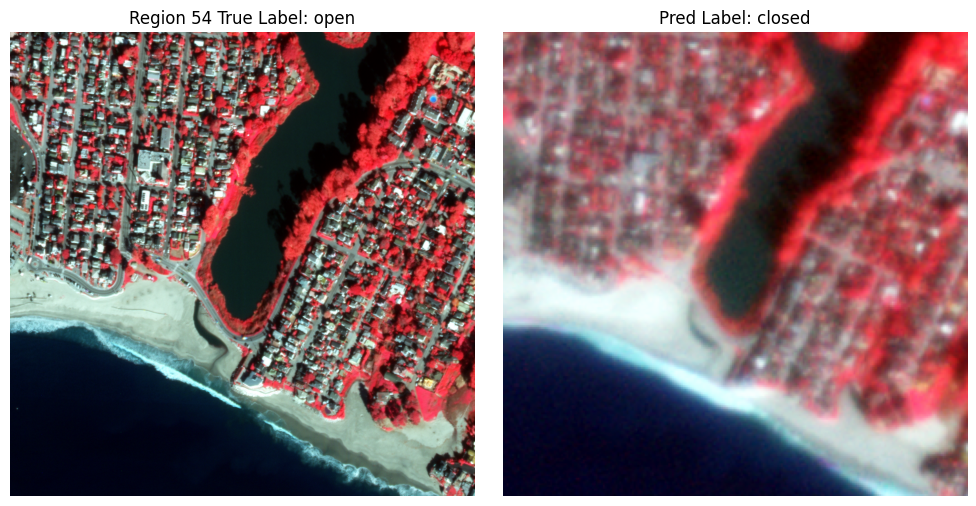

In [13]:
inspect_row(inspect_iter, "_ss", "_dd")

In [14]:
dd_pairs.label_water.value_counts()

label_water
closed          537
open            515
perched open     70
Name: count, dtype: int64

In [15]:
dd_pairs.columns

Index(['region', 'source_tif_img', 'label_img', 'acquired_img',
       'instrument_img', 'year_img', 'month_img', 'asset_id',
       'source_tif_water', 'label_water', 'acquired_water', 'instrument_water',
       'year_water', 'month_water'],
      dtype='object')

Accuracy 3 class 82.0
Perched F1 59.1


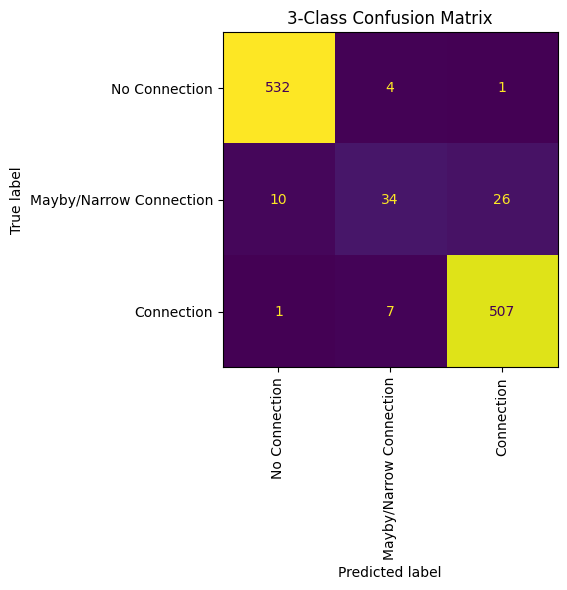

Accuracy Connection (Maybe as connection) 98.6


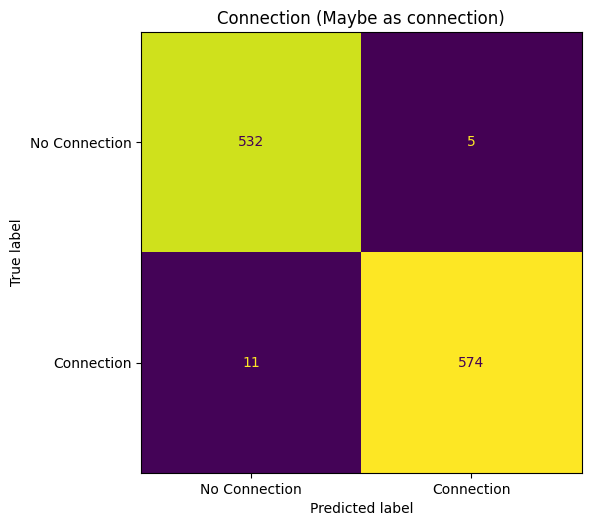

Connection (Maybe as connection) 99.8


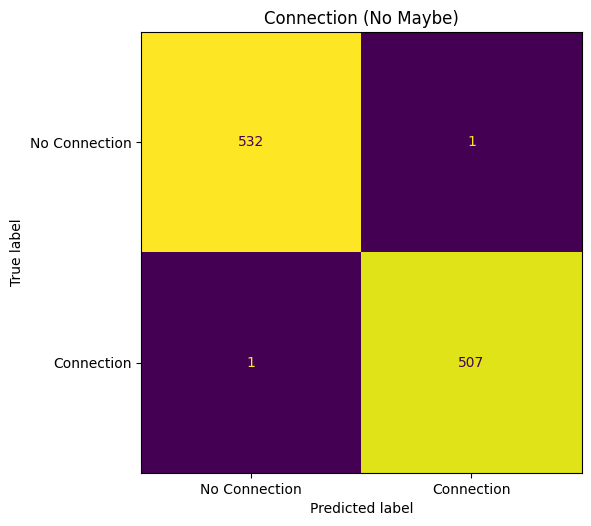

In [16]:
labels = ["closed", "perched open", "open"]
disp_labels = ["No Connection", "Mayby/Narrow Connection", "Connection"]
y_true = np.array([labels.index(l) for l in dd_pairs.label_water])
y_pred = np.array([labels.index(l) for l in dd_pairs.label_img])

print("Accuracy 3 class", round(100 * balanced_accuracy_score(y_true, y_pred), 1))
print("Perched F1", round(100 * f1_score(y_true == 1, y_pred == 1), 1))

fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=disp_labels,
    ax=ax,
    colorbar=False,
    xticks_rotation="vertical",
)

ax.set_title("3-Class Confusion Matrix")

fig.tight_layout()
fig.savefig(SAVE_DIR / "cm_3class_dove_water.png", dpi=300)
plt.show()

labels = ["closed", "open"]
disp_labels = ["No Connection", "Connection"]
y_true = [int("open" in l) for l in dd_pairs.label_water]
y_pred = [int("open" in l) for l in dd_pairs.label_img]

print(
    "Accuracy Connection (Maybe as connection)",
    round(100 * balanced_accuracy_score(y_true, y_pred), 1),
)

fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=disp_labels,
    ax=ax,
    colorbar=False,
)

ax.set_title("Connection (Maybe as connection)")

fig.tight_layout()
fig.savefig(SAVE_DIR / "cm_open_closed_dove_water.png", dpi=300)
plt.show()

y_true = [
    int("open" in l)
    for l, p in zip(dd_pairs.label_water, dd_pairs.label_img)
    if "perch" not in l and "perch" not in p
]
y_pred = [
    int("open" in p)
    for l, p in zip(dd_pairs.label_water, dd_pairs.label_img)
    if "perch" not in l and "perch" not in p
]

print("Connection (Maybe as connection)", round(100 * balanced_accuracy_score(y_true, y_pred), 1))

fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=disp_labels,
    ax=ax,
    colorbar=False,
)

ax.set_title("Connection (No Maybe)")

fig.tight_layout()
fig.savefig(SAVE_DIR / "cm_no_perch_dove_water.png", dpi=300)
plt.show()

In [17]:
# inspect_d = pd.concat(
#     [
#         dd_pairs[(dd_pairs.label_water == "closed") & (dd_pairs.label_img == "open")],
#         dd_pairs[(dd_pairs.label_water == "open") & (dd_pairs.label_img == "closed")],
#     ]
# )
inspect_d = dd_pairs[(dd_pairs.label_water == "perched open") & (dd_pairs.label_img == "closed")]
inspect_d_iter = inspect_d.iterrows()

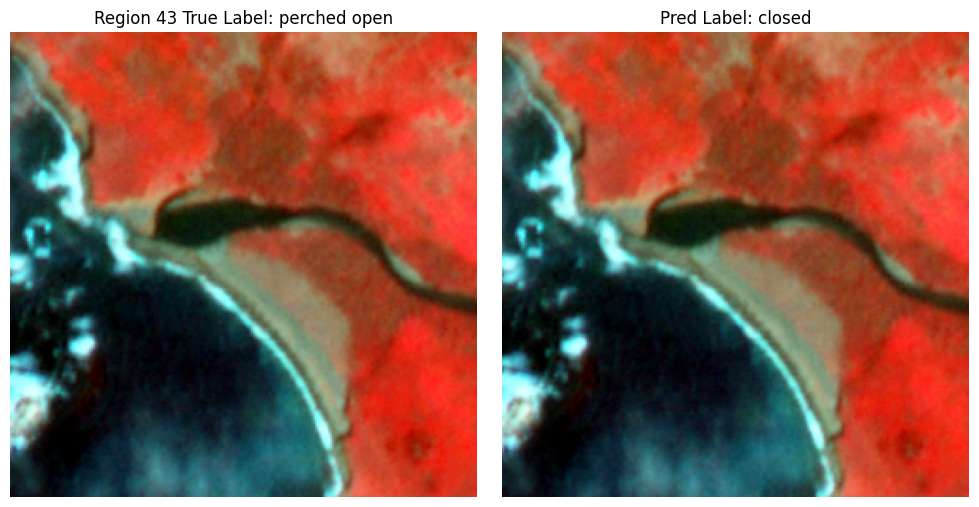

In [18]:
inspect_row(inspect_d_iter, "_water", "_img")

In [19]:
non_merged_preds = pd.read_csv(
    "/Users/kyledorman/data/results/estuary/train/20260302-151805/all_regions_timeseries_preds.csv"
)
len(non_merged_preds), (non_merged_preds.y_pred_unsure != 1).sum().item()

(101458, 95925)

In [20]:
train_preds = pd.read_csv(
    "/Users/kyledorman/data/results/estuary/train/20260302-151805/train_preds.csv"
)
len(train_preds), (train_preds.y_pred_unsure != 1).sum().item()

(12592, 10610)

In [21]:
preds_all_orig = pd.read_csv(
    "/Users/kyledorman/data/results/estuary/train/20260224-123117/merged_all_regions_timeseries_preds.csv"
)

preds_all_orig["acquired"] = pd.to_datetime(preds_all_orig["acquired"], errors="coerce", utc=True)
preds_all_orig["date"] = preds_all_orig.acquired.dt.date
preds_all_orig["month"] = preds_all_orig.acquired.dt.month
preds_all_orig["year"] = preds_all_orig.acquired.dt.year
preds_all = preds_all_orig.copy()
preds_all = (
    preds_all[(preds_all.region.isin(gdf.index)) & (preds_all.y_pred_unsure != 1)]
    .copy()
    .sort_values(by=["region", "acquired"])
    .reset_index(drop=True)
)

preds_all.head(3)

,region,date,y_true,y_true_unsure,acquired,source_tif,y_pred_unsure,y_pred,openness,p_closed,p_perched_open,p_open,month,year
0,11,2017-02-01,1,0,2017-02-01 17:46:04+00:00,/Volumes/x10pro/estuary/sat_data/dove/results/...,0,2.0,0.842874,0.078563,0.035938,0.885499,2,2017
1,11,2017-02-10,1,0,2017-02-10 17:45:58+00:00,/Volumes/x10pro/estuary/sat_data/dove/results/...,0,2.0,0.766740,0.116630,0.007785,0.875585,2,2017
2,11,2017-02-25,1,0,2017-02-25 17:46:40+00:00,/Volumes/x10pro/estuary/sat_data/dove/results/...,0,2.0,0.999906,0.000047,0.000015,0.999938,2,2017


In [22]:
train_preds.y_true.value_counts()

y_true
 0    4929
 2    4131
-1    2599
 1     933
Name: count, dtype: int64

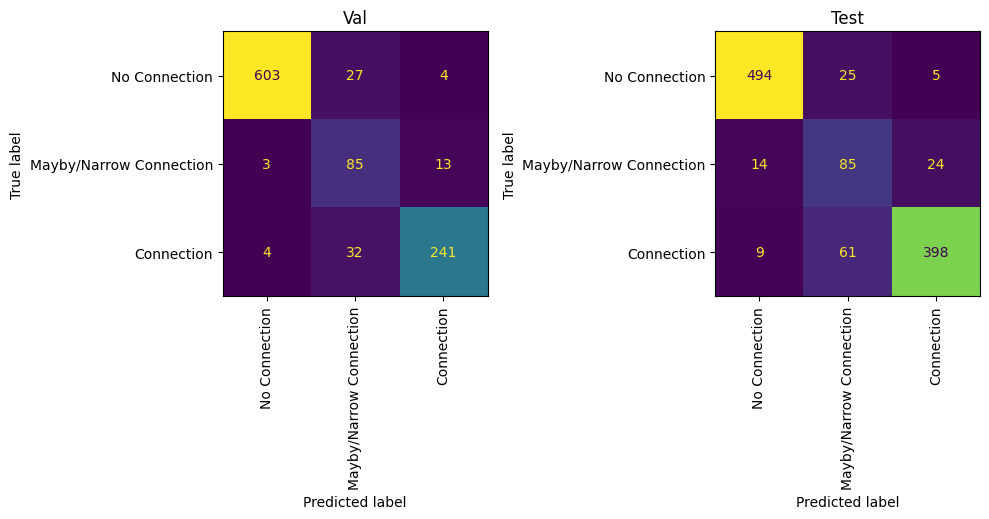

In [23]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

preds_21 = train_preds[(train_preds.year == 2021) & (train_preds.y_true >= 0)]
preds_25 = train_preds[(train_preds.year == 2025) & (train_preds.y_true >= 0)]

disp_labels = ["No Connection", "Mayby/Narrow Connection", "Connection"]
y_true = preds_21.y_true
y_pred = preds_21.y_pred

disp = ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=disp_labels,
    ax=axes[0],
    colorbar=False,
    xticks_rotation="vertical",
)

axes[0].set_title("Val")

y_true = preds_25.y_true
y_pred = preds_25.y_pred

disp = ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=disp_labels,
    ax=axes[1],
    colorbar=False,
    xticks_rotation="vertical",
)

axes[1].set_title("Test")

fig.tight_layout()
# fig.savefig(SAVE_DIR / "cm_open_closed_dove_water.png", dpi=300)
plt.show()

In [24]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

LABELS_3 = ["closed", "perched open", "open"]
LABELS_2 = ["not closed", "closed"]  # note: 0=not-closed, 1=closed in our mapping below


def _macro_f1_3(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro", labels=[0, 1, 2], zero_division=1)


def _per_class_f1_3(y_true, y_pred):
    # returns array [f1_closed, f1_perched, f1_open]
    return f1_score(y_true, y_pred, average=None, labels=[0, 1, 2], zero_division=1)


def _to_closed_vs_not(y):
    # your definition: "closed" is class 0
    return (np.asarray(y) == 0).astype(int)  # 1=closed, 0=not-closed


def _macro_f1_2(y_true2, y_pred2):
    return f1_score(y_true2, y_pred2, average="macro", labels=[0, 1], zero_division=1)


def _per_class_f1_2(y_true2, y_pred2):
    # returns array [f1_not_closed, f1_closed]
    return f1_score(y_true2, y_pred2, average=None, labels=[0, 1], zero_division=1)


def summarize_split_3class(df: pd.DataFrame, split_name: str, region_col: str = "region") -> dict:
    df = df[(df["y_true"] >= 0) & (df["y_pred"] >= 0)].copy()
    y_true = df["y_true"].to_numpy()
    y_pred = df["y_pred"].to_numpy()

    f1_macro = _macro_f1_3(y_true, y_pred)
    f1_closed, f1_perched, f1_open = _per_class_f1_3(y_true, y_pred).tolist()

    # per-region macro F1 (3-class)
    per_region = (
        df.groupby(region_col)
        .apply(
            lambda g: _macro_f1_3(g["y_true"].to_numpy(), g["y_pred"].to_numpy()),
            include_groups=False,
        )
        .rename("f1_macro_3")
    )
    min_region = per_region.idxmin()
    min_region_f1 = float(per_region.loc[min_region])
    mean_region_f1 = float(per_region.mean())
    std_region_f1 = float(per_region.std())

    return {
        "split": split_name,
        "n": len(df),
        "f1": f1_macro,
        "f1_no_conn": f1_closed,
        "f1_maybe_conn": f1_perched,
        "f1_conn": f1_open,
        "min_region_f1": min_region_f1,
        "min_region": min_region,
        "mean_region_f1": mean_region_f1,
    }


def summarize_split_2class(df: pd.DataFrame, split_name: str, region_col: str = "region") -> dict:
    df = df[(df["y_true"] >= 0) & (df["y_pred"] >= 0)].copy()

    y_true2 = _to_closed_vs_not(df["y_true"].to_numpy())  # 1=closed, 0=not-closed
    y_pred2 = _to_closed_vs_not(df["y_pred"].to_numpy())

    f1_macro = _macro_f1_2(y_true2, y_pred2)
    f1_not_closed, f1_closed = _per_class_f1_2(y_true2, y_pred2).tolist()

    # per-region macro F1 (2-class)
    per_region = (
        df.assign(y_true2=y_true2, y_pred2=y_pred2)
        .groupby(region_col)
        .apply(
            lambda g: _macro_f1_2(g["y_true2"].to_numpy(), g["y_pred2"].to_numpy()),
            include_groups=False,
        )
        .rename("f1_macro_2")
    )
    min_region = per_region.idxmin()
    min_region_f1 = float(per_region.loc[min_region])
    mean_region_f1 = float(per_region.mean())
    std_region_f1 = float(per_region.std())

    return {
        "split": split_name,
        "n": len(df),
        "f1": f1_macro,
        "min_region_f1": min_region_f1,
        "min_region": min_region,
        "mean_region_f1": mean_region_f1,
    }


# ---- Build the two paper-ready tables ----
preds_val = train_preds[(train_preds.year == 2021) & (train_preds.y_true >= 0)]
preds_test = train_preds[(train_preds.year == 2025) & (train_preds.y_true >= 0)]
preds_train = train_preds[(~train_preds.year.isin([2025, 2021])) & (train_preds.y_true >= 0)]

table_3 = pd.DataFrame(
    [
        summarize_split_3class(preds_val, "val (2021)", region_col="region"),
        summarize_split_3class(preds_test, "test (2025)", region_col="region"),
        # summarize_split_3class(preds_train, "train", region_col="region"),
    ]
)

table_2 = pd.DataFrame(
    [
        summarize_split_2class(preds_val, "val (2021)", region_col="region"),
        summarize_split_2class(preds_test, "test (2025)", region_col="region"),
        # summarize_split_2class(preds_train, "train", region_col="region"),
    ]
)


# Optional: convert F1 columns to percent for paper tables
def to_percent_table(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c in out.columns:
        if c.startswith("f1_") and out[c].dtype != object:
            out[c] = (100.0 * out[c]).round(1)
    return out


table_3_pct = to_percent_table(table_3)
table_2_pct = to_percent_table(table_2)

display(table_3_pct.round(2))
display(table_2_pct.round(2))

,split,n,f1,f1_no_conn,f1_maybe_conn,f1_conn,min_region_f1,min_region,mean_region_f1
0,val (2021),1012,0.85,96.9,69.4,90.1,0.31,12097,0.84
1,test (2025),1115,0.81,94.9,57.8,88.9,0.31,21,0.78


,split,n,f1,min_region_f1,min_region,mean_region_f1
0,val (2021),1012,0.96,0.48,12103,0.93
1,test (2025),1115,0.95,0.46,32,0.91


In [25]:
a = preds_test[preds_test.region == 62]
(a.y_pred == a.y_true).sum() / len(a)

np.float64(0.6956521739130435)

In [26]:
import matplotlib.pyplot as plt


def save_table_png(df: pd.DataFrame, path: str, title: str = None):
    fig, ax = plt.subplots(figsize=(1.6 * len(df.columns), 1 + 0.5 * len(df)))
    ax.axis("off")

    if title:
        ax.set_title(title, fontsize=14, pad=12)

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        loc="center",
        cellLoc="center",
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.4)

    # Bold header row
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold")

    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.close(fig)

In [27]:
table_3_fmt = table_3_pct.rename(
    columns={
        "split": "Split",
        "n": "N",
        "f1": "F1 (3-Class)",
        "f1_no_conn": "F1: No Connection",
        "f1_maybe_conn": "F1: Narrow/Perched",
        "f1_conn": "F1: Connection",
        "min_region_f1": "Worst Region F1",
        "mean_region_f1": "Mean Region F1",
    }
).drop(columns=["min_region"])

save_table_png(table_3_fmt.round(2), SAVE_DIR / "results_3class.png", title="3-Class Results")

In [28]:
table_2_fmt = table_2_pct.rename(
    columns={
        "split": "Split",
        "n": "N",
        "f1": "F1 (2-Class)",
        "min_region_f1": "Worst Region F1",
        "mean_region_f1": "Mean Region F1",
    }
).drop(columns=["min_region"])

save_table_png(table_2_fmt.round(2), SAVE_DIR / "results_2class.png", title="2-Class Results")

In [29]:
import numpy as np
import pandas as pd

disp_labels = ["No Connection", "Mayby/Narrow Connection", "Connection"]
all_classes = ["Low Quality"] + disp_labels


def summarize_dataset(df: pd.DataFrame, name: str) -> dict:
    df = df.copy()

    # Map predictions to display label
    df["label"] = np.where(
        df["y_pred_unsure"], "Low Quality", df["y_pred"].map(dict(enumerate(disp_labels)))
    )

    total = len(df)
    counts = df["label"].value_counts().reindex(all_classes, fill_value=0)

    row = {"Dataset": name, "N": total}

    for cls in all_classes:
        c = counts[cls]
        pct = 100 * c / total if total > 0 else 0
        # row[f"{cls} (n)"] = c
        row[f"{cls} (%)"] = round(pct, 1)

    return row


table = pd.DataFrame(
    [
        summarize_dataset(non_merged_preds, "All Predictions"),
        summarize_dataset(preds_all_orig, "Merged Same-Day"),
    ]
)

table

,Dataset,N,Low Quality (%),No Connection (%),Mayby/Narrow Connection (%),Connection (%)
0,All Predictions,101458,5.5,50.2,13.2,31.1
1,Merged Same-Day,76621,5.2,49.0,12.3,33.5


In [37]:
non_merged_preds[
    (non_merged_preds.region == 97)
    & (non_merged_preds.y_pred == 0)
    & (non_merged_preds.y_pred_unsure == False)
].source_tif.iloc[0]

'/Volumes/x10pro/estuary/sat_data/superdove/results/2025/9/97/files/20250926_193215_86_24dc_3B_AnalyticMS_SR_8b_clip.tif'

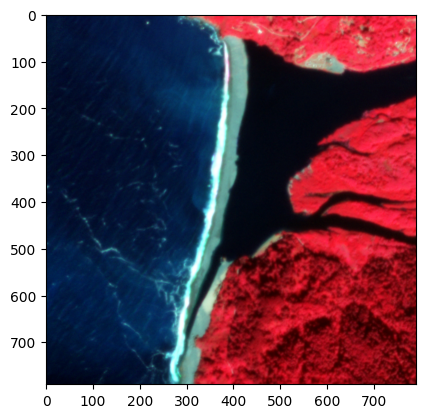

In [38]:
pth = "/Volumes/x10pro/estuary/sat_data/superdove/results/2025/9/97/files/20250926_193215_86_24dc_3B_AnalyticMS_SR_8b_clip.tif"

with rasterio.open(pth) as src:
    data = src.read().astype(np.float32)
    nodata = src.read(1, masked=True).mask
    img = false_color(data, nodata)

plt.figure()
plt.imshow(img)

In [39]:
pct_by_region = (
    preds_all.groupby("region")["y_pred"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .rename(columns={0: "closed_pct", 1: "perched_pct", 2: "open_pct"})
)

pct_by_region

y_pred,closed_pct,perched_pct,open_pct
region,,,
11,0.072500,0.000000,0.927500
14,0.249147,0.017918,0.732935
15,0.101844,0.009658,0.888499
16,0.937449,0.035391,0.027160
17,0.848612,0.015980,0.135408
...,...,...,...
13027,0.920160,0.061876,0.017964
13057,0.366748,0.222494,0.410758
13073,0.850272,0.104356,0.045372


In [47]:
pct_by_region[pct_by_region.open_pct > 0.99]

y_pred,closed_pct,perched_pct,open_pct
region,,,
97,0.002841,0.0,0.997159
12105,0.000000,0.0,1.000000


In [153]:
ca = gpd.read_file("/Volumes/x10pro/estuary/geos/ca_geo.geojson")
pmep_points = gpd.read_file("/Volumes/x10pro/estuary/geos/PMEP_Estuary_Points_V1_3.gdb/").to_crs(
    ca.crs
)

# Goleta Slough too close to San Pedro Creek, we see both!
pmep_points = pmep_points[pmep_points.PMEP_EstuaryID != 4003].copy()

pmep_points = pmep_points[pmep_points.intersects(ca.iloc[0].geometry)].copy()
print(len(pmep_points))
pmep_points.head()

189


/Users/kyledorman/Documents/UCLA_kelp/estuary/.venv/lib/python3.12/site-packages/pyogrio/raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D Point' is converted to 'Point Z'
  return ogr_read(


,PMEP_EstuaryID,Estuary_Name,Data_Source,CMECS_Class,PMEP_Region,System_Order,Estuary_Hectares,Link,geometry
253,2087,Smith River,PMEP,Riverine Estuary,"Washington, Oregon, Northern California Coast",120.0,481.289637,2087_Smith River,POINT Z (-124.18315 41.91363 0.00013)
254,2088,Lake Earl,PMEP,Lagoonal Estuary,"Washington, Oregon, Northern California Coast",121.0,1609.386192,2088_Lake Earl,POINT Z (-124.19721 41.82226 0.00013)
255,2089,Pebble Beach,PMEP,Lagoonal Estuary,"Washington, Oregon, Northern California Coast",122.0,14.537437,2089_Pebble Beach,POINT Z (-124.22426 41.76496 0.00013)
256,2090,Crescent City Harbor,PMEP,Embayment/Bay,"Washington, Oregon, Northern California Coast",123.0,188.965914,2090_Crescent City Harbor,POINT Z (-124.19052 41.74395 0.00013)
257,2091,NC9 Cresent Beach,PMEP,Lagoonal Estuary,"Washington, Oregon, Northern California Coast",124.0,7.051772,2091_NC9 Cresent Beach,POINT Z (-124.15027 41.72553 0.00013)


In [83]:
gdf = gpd.read_file("/Volumes/x10pro/estuary/geos/ca_data_w_empa_pmep_usgs.geojson")
gdf = gdf[gdf.skipped == False].copy()
gdf["in_dataset"] = True

gdf.head()

,Site code,Site name,skipped,PMEP_EstuaryID,Estuary_Name,Data_Source,CMECS_Class,PMEP_Region,System_Order,Estuary_Hectares,...,point_geom_lat,point_geom_long,pmep_pt_geom_lat,pmep_pt_geom_long,usgs_station_nm,usgs_site_no,usgs_site_latitude,usgs_site_longitude,geometry,in_dataset
0,11,Los Penasquitos Lagoon,False,4056.0,Los Penasquitos Lagoon,PMEP,Lagoonal Estuary,Southern California Bight,299.0,95.475975,...,32.933,-117.260,32.931536,-117.256714,None,None,None,None,"POLYGON ((-117.25816 32.93218, -117.25817 32.9...",True
1,18,Zuma Lagoon,False,4018.0,Zuma Canyon,PMEP,Lagoonal Estuary,Southern California Bight,262.0,1.779315,...,34.015,-118.821,34.014565,-118.820618,None,None,None,None,"POLYGON ((-118.81685 34.01177, -118.81699 34.0...",True
2,21,Ventura River,False,4010.0,Ventura River,PMEP,Lagoonal Estuary,Southern California Bight,253.0,17.225009,...,34.276,-119.308,34.277309,-119.308329,None,None,None,None,"POLYGON ((-119.30473 34.27203, -119.3049 34.27...",True
3,48,Carmel River,False,3080.0,Carmel River,PMEP,Lagoonal Estuary,Central California,216.0,37.647248,...,36.537,-121.927,36.537940,-121.923722,None,None,None,None,"POLYGON ((-121.92421 36.53429, -121.92412 36.5...",True
4,50,Salinas River,False,3079.0,Salinas River,PMEP,Lagoonal Estuary,Central California,215.0,211.011888,...,36.748,-121.801,36.737644,-121.790315,None,None,None,None,"POLYGON ((-121.79521 36.74436, -121.79499 36.7...",True


In [84]:
joined = pmep_points.join(
    gdf[
        ["PMEP_EstuaryID", "in_dataset", "Site name", "point_geom_lat", "point_geom_long"]
    ].set_index("PMEP_EstuaryID"),
    on="PMEP_EstuaryID",
    how="outer",
)

# 1. fill in_dataset
joined["in_dataset"] = joined["in_dataset"].fillna(False)

# 2. build geometry for rows missing PMEP_EstuaryID
mask = joined["PMEP_EstuaryID"].isna()

joined.loc[mask, "CMECS_Class"] = "Lagoonal Estuary"

joined.loc[mask, "geometry"] = gpd.points_from_xy(
    joined.loc[mask, "point_geom_long"], joined.loc[mask, "point_geom_lat"]
)

joined.loc[mask, "Estuary_Name"] = joined.loc[mask, "Site name"]

joined.loc[mask, "Estuary_Hectares"] = 50.0

# 3. drop temporary columns
joined = joined.drop(columns=["point_geom_lat", "point_geom_long", "Site name"])

# 4. ensure it's still a GeoDataFrame
joined = gpd.GeoDataFrame(joined, geometry="geometry", crs=pmep_points.crs)

joined.head()

/var/folders/pr/1dt1qk511zdgzhfy1xskpqm00000gn/T/ipykernel_43714/1399459343.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  joined["in_dataset"] = joined["in_dataset"].fillna(False)


,PMEP_EstuaryID,Estuary_Name,Data_Source,CMECS_Class,PMEP_Region,System_Order,Estuary_Hectares,Link,geometry,in_dataset
253.0,2087.0,Smith River,PMEP,Riverine Estuary,"Washington, Oregon, Northern California Coast",120.0,481.289637,2087_Smith River,POINT Z (-124.18315 41.91363 0.00013),False
254.0,2088.0,Lake Earl,PMEP,Lagoonal Estuary,"Washington, Oregon, Northern California Coast",121.0,1609.386192,2088_Lake Earl,POINT Z (-124.19721 41.82226 0.00013),True
255.0,2089.0,Pebble Beach,PMEP,Lagoonal Estuary,"Washington, Oregon, Northern California Coast",122.0,14.537437,2089_Pebble Beach,POINT Z (-124.22426 41.76496 0.00013),False
256.0,2090.0,Crescent City Harbor,PMEP,Embayment/Bay,"Washington, Oregon, Northern California Coast",123.0,188.965914,2090_Crescent City Harbor,POINT Z (-124.19052 41.74395 0.00013),False
257.0,2091.0,NC9 Cresent Beach,PMEP,Lagoonal Estuary,"Washington, Oregon, Northern California Coast",124.0,7.051772,2091_NC9 Cresent Beach,POINT Z (-124.15027 41.72553 0.00013),False


In [102]:
import folium
import numpy as np

f = pmep_points[pmep_points.CMECS_Class != "Embayment/Bay"]

# Center map
m = folium.Map(
    location=[f.geometry.y.mean(), f.geometry.x.mean()],
    zoom_start=6,
    tiles="CartoDB positron",
)

# --- Size scaling ---
hectares = f["Estuary_Hectares"].fillna(0)

min_r = 3
max_r = 12

scaled = np.sqrt(hectares)
scaled = (scaled - scaled.min()) / (scaled.max() - scaled.min())
radii = min_r + scaled * (max_r - min_r)

# --- Color mapping ---
classes = sorted(f["CMECS_Class"].dropna().unique())

palette = [
    "#1b9e77",
    "#d95f02",
    "#7570b3",
    "#e7298a",
    "#66a61e",
    "#e6ab02",
    "#a6761d",
    "#666666",
]

color_map = dict(zip(classes, palette[: len(classes)]))

# --- Plot points ---
for (_, row), r in zip(f.iterrows(), radii):
    cls = row["CMECS_Class"]
    color = color_map.get(cls, "#999999")

    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=r,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        weight=1,
        tooltip=f"""
        <b>{row.get("Estuary_Name", "")}</b><br>
        CMECS: {cls}<br>
        Area: {row["Estuary_Hectares"]:.1f} ha
        """,
    ).add_to(m)

# --- Legend ---
legend_html = """
<div style="
position: fixed;
bottom: 50px;
left: 50px;
width: 250px;
background-color: white;
border:2px solid grey;
z-index:9999;
font-size:14px;
padding:10px;
">
<b>CMECS Class</b><br>
"""

for cls, color in color_map.items():
    legend_html += f"""
    <i style="background:{color};
              width:12px;
              height:12px;
              display:inline-block;
              margin-right:6px;"></i>{cls}<br>
    """

legend_html += "</div>"

m.get_root().html.add_child(folium.Element(legend_html))

m

In [108]:
df["CMECS_Class"].unique()

array(['Riverine Estuary', 'Lagoonal Estuary', 'Embayment/Bay'],
      dtype=object)

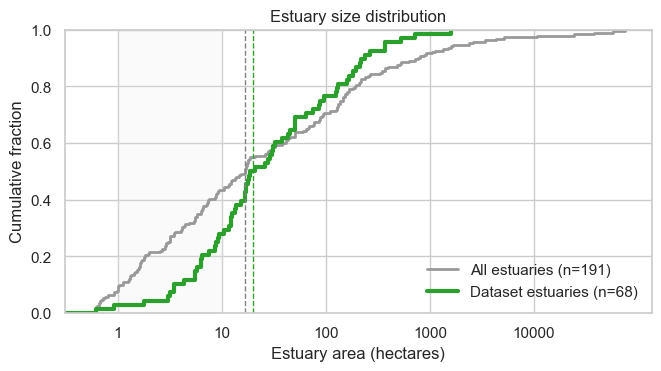

In [122]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = joined.copy()
df = df[df["Estuary_Hectares"].notna()].copy()
df["in_dataset"] = df["in_dataset"].fillna(False)

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(6.5, 3.6), constrained_layout=True)

# --- ECDF: all estuaries ---
sns.ecdfplot(
    data=df, x="Estuary_Hectares", ax=ax, color="0.6", lw=2, label=f"All estuaries (n={len(df)})"
)

# --- ECDF: dataset estuaries ---
sns.ecdfplot(
    data=df[df["in_dataset"]],
    x="Estuary_Hectares",
    ax=ax,
    color="#2ca02c",
    lw=3,
    label=f"Dataset estuaries (n={df['in_dataset'].sum()})",
)

# --- Median reference lines (optional but nice) ---
ax.axvline(df["Estuary_Hectares"].median(), color="0.5", lw=1, ls="--")
ax.axvline(df[df["in_dataset"]]["Estuary_Hectares"].median(), color="#2ca02c", lw=1, ls="--")

# --- Log axis ---
ax.set_xscale("log")

# Better tick labels for papers
ticks = [1, 10, 100, 1000, 10000]
ax.set_xticks(ticks)
ax.set_xticklabels([str(t) for t in ticks])

ax.set_xlabel("Estuary area (hectares)")
ax.set_ylabel("Cumulative fraction")
ax.set_title("Estuary size distribution")

ax.legend(frameon=False)

plt.show()

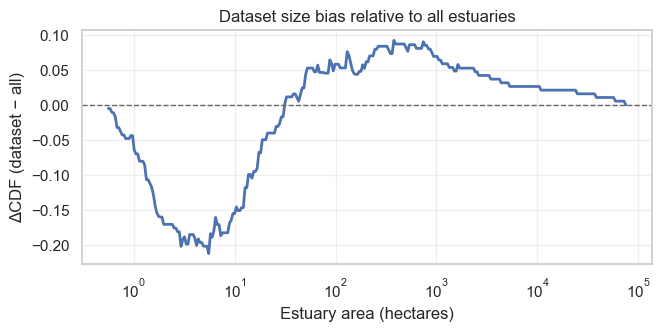

In [120]:
import matplotlib.pyplot as plt
import numpy as np

df = joined.copy()
df = df[df["Estuary_Hectares"].notna()].copy()

all_sizes = df["Estuary_Hectares"].to_numpy()
ds_sizes = df.loc[df["in_dataset"].fillna(False), "Estuary_Hectares"].to_numpy()

# Common x-grid (log-spaced)
xmin = max(1e-2, np.nanmin(all_sizes))
xmax = np.nanmax(all_sizes)
x = np.logspace(np.log10(xmin), np.log10(xmax), 300)


def ecdf_values(samples, xgrid):
    s = np.sort(samples)
    return np.searchsorted(s, xgrid, side="right") / len(s)


F_all = ecdf_values(all_sizes, x)
F_ds = ecdf_values(ds_sizes, x)

delta = F_ds - F_all

fig, ax = plt.subplots(figsize=(6.5, 3.2), constrained_layout=True)
ax.plot(x, delta, lw=2)

ax.axhline(0, color="0.4", lw=1, ls="--")
ax.set_xscale("log")
ax.set_xlabel("Estuary area (hectares)")
ax.set_ylabel("ΔCDF (dataset − all)")
ax.set_title("Dataset size bias relative to all estuaries")
ax.grid(True, alpha=0.3)

plt.show()

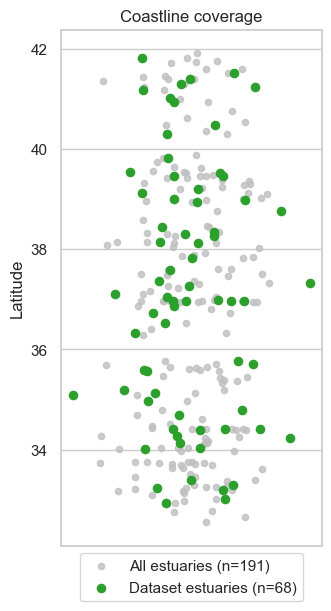

In [143]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = joined.copy()
df = df[df.geometry.notna()].copy()
df["in_dataset"] = df["in_dataset"].fillna(False)

df["lat"] = df.geometry.y

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(3.2, 6), constrained_layout=True)

rng = np.random.default_rng(0)

# jitter so dots don't overlap
jitter_all = rng.normal(0, 0.02, len(df))
jitter_ds = rng.normal(0, 0.02, df["in_dataset"].sum())

# all estuaries
ax.scatter(
    jitter_all,
    df["lat"],
    s=20,
    color="0.75",
    alpha=0.8,
    label=f"All estuaries (n={len(df)})",
)

# dataset estuaries
ax.scatter(
    jitter_ds,
    df.loc[df["in_dataset"], "lat"],
    s=35,
    color="#2ca02c",
    label=f"Dataset estuaries (n={df['in_dataset'].sum()})",
)

ax.set_xticks([])
ax.set_xlabel("")
ax.set_ylabel("Latitude")

ax.set_title("Coastline coverage")

ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.00), ncol=1, frameon=True)

plt.show()

/var/folders/pr/1dt1qk511zdgzhfy1xskpqm00000gn/T/ipykernel_43714/4148897415.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_all = df.groupby("lat_bin").size()
/var/folders/pr/1dt1qk511zdgzhfy1xskpqm00000gn/T/ipykernel_43714/4148897415.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_ds = df[df["in_dataset"]].groupby("lat_bin").size()


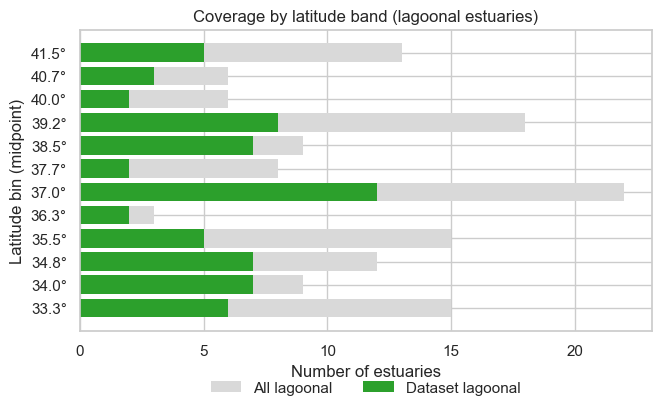

In [151]:
df = joined.copy()
df = df[df.geometry.notna()].copy()
df["in_dataset"] = df["in_dataset"].fillna(False).astype(bool)
df = df[df["CMECS_Class"] == "Lagoonal Estuary"].copy()

df["lat"] = df.geometry.y

# pick number of bands (10–14 works well)
n_bins = 12
bins = np.linspace(df["lat"].min(), df["lat"].max(), n_bins + 1)

df["lat_bin"] = pd.cut(df["lat"], bins=bins, include_lowest=True)

counts_all = df.groupby("lat_bin").size()
counts_ds = df[df["in_dataset"]].groupby("lat_bin").size()

# align and fill missing
counts_all = counts_all.sort_index()
counts_ds = counts_ds.reindex(counts_all.index, fill_value=0)

# y positions (one per bin)
y = np.arange(len(counts_all))

fig, ax = plt.subplots(figsize=(6.5, 4.0), constrained_layout=True)

# background: all lagoonal
ax.barh(y, counts_all.values, color="0.85", edgecolor="none", label="All lagoonal")

# overlay: dataset lagoonal
ax.barh(y, counts_ds.values, color="#2ca02c", edgecolor="none", label="Dataset lagoonal")

# labels as bin midpoints (lat)
bin_mids = np.array([(b.left + b.right) / 2 for b in counts_all.index])
ax.set_yticks(y)
ax.set_yticklabels([f"{m:.1f}°" for m in bin_mids])

ax.set_xlabel("Number of estuaries")
ax.set_ylabel("Latitude bin (midpoint)")
ax.set_title("Coverage by latitude band (lagoonal estuaries)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)

plt.show()

/Users/kyledorman/Documents/UCLA_kelp/estuary/.venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/kyledorman/Documents/UCLA_kelp/estuary/.venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


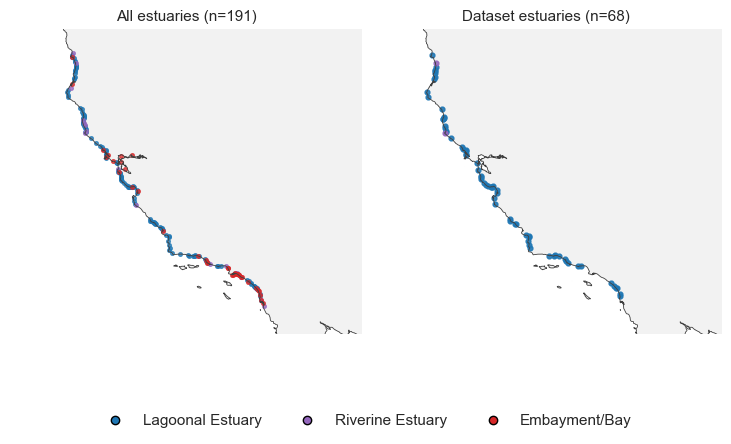

In [155]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

df = joined.copy()
df = df[df.geometry.notna()].copy()
df["in_dataset"] = df["in_dataset"].fillna(False).astype(bool)

# Keep only rows with CMECS_Class (optional)
df["CMECS_Class"] = df["CMECS_Class"].fillna("Unknown")

# Choose which classes to show (keeps legend manageable)
# (If you want all unique classes, set classes = sorted(df["CMECS_Class"].unique()))
classes = ["Lagoonal Estuary", "Riverine Estuary", "Embayment/Bay", "Unknown"]
present = [c for c in classes if (df["CMECS_Class"] == c).any()]
classes = present

palette = {
    "Lagoonal Estuary": "#1f77b4",
    "Riverine Estuary": "#9467bd",
    "Embayment/Bay": "#d62728",
    "Unknown": "0.6",
}

# CA extent
minx, maxx = -126.5, -113.5
miny, maxy = 31.5, 42.8

proj = ccrs.PlateCarree()
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(7.2, 5.0),
    subplot_kw={"projection": proj},
    constrained_layout=True,
)


def setup_ax(ax, title):
    ax.set_extent([minx, maxx, miny, maxy], crs=proj)
    ax.add_feature(cfeature.LAND.with_scale("10m"), facecolor="0.95", edgecolor="none")
    ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="white", edgecolor="none")
    ax.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=0.6, color="0.25")
    ax.axis("off")
    ax.set_title(title, fontsize=11)


def plot_points(ax, d, size=8, alpha=0.85):
    for cls in classes:
        g = d[d["CMECS_Class"] == cls]
        if g.empty:
            continue
        ax.scatter(
            g.geometry.x,
            g.geometry.y,
            s=size,
            color=palette.get(cls, "0.6"),
            alpha=alpha,
            transform=proj,
            rasterized=True,
        )


# Left: all estuaries
setup_ax(axes[0], f"All estuaries (n={len(df)})")
plot_points(axes[0], df, size=7, alpha=0.75)

# Right: dataset only
ds = df[df["in_dataset"]]
setup_ax(axes[1], f"Dataset estuaries (n={len(ds)})")
plot_points(axes[1], ds, size=12, alpha=0.9)

# Shared legend
handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor=palette.get(cls, "0.6"),
        markersize=6,
        label=cls,
    )
    for cls in classes
]
fig.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=min(4, len(handles)),
    frameon=False,
)

plt.show()

/Users/kyledorman/Documents/UCLA_kelp/estuary/.venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


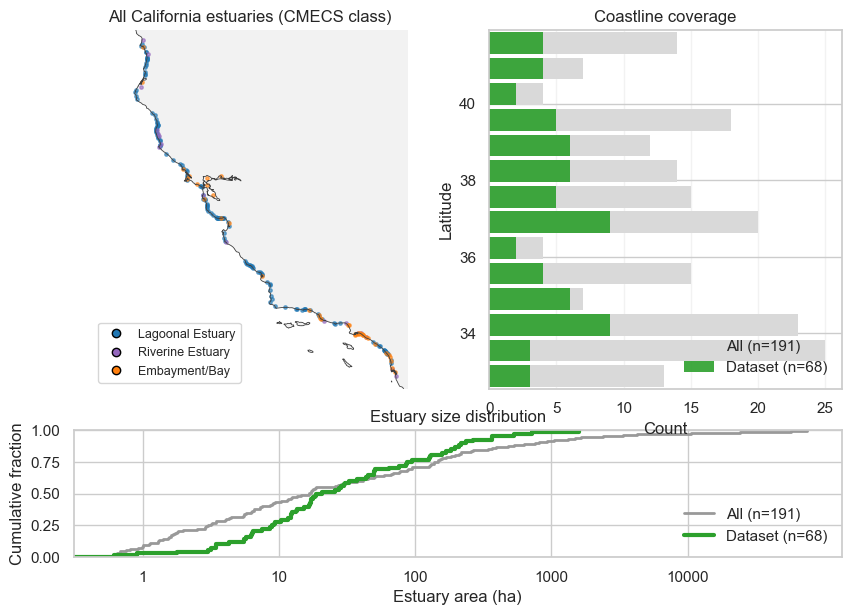

In [174]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.lines import Line2D


def make_opening_figure(joined):
    # --- prep ---
    df = joined.copy()
    df = df[df.geometry.notna()].copy()
    df["in_dataset"] = df["in_dataset"].fillna(False).astype(bool)
    df["CMECS_Class"] = df["CMECS_Class"].fillna("Unknown")

    # Use lagoonal-only for strip+ECDF if you want (recommended for your story)
    # df_lag = df[df["CMECS_Class"] == "Lagoonal Estuary"].copy()
    df_lag = df

    sns.set_theme(style="whitegrid")

    # Map classes (keep legend manageable)
    classes = ["Lagoonal Estuary", "Riverine Estuary", "Embayment/Bay", "Unknown"]
    classes = [c for c in classes if (df["CMECS_Class"] == c).any()]

    palette = {
        "Lagoonal Estuary": "#1f77b4",  # blue
        "Riverine Estuary": "#9467bd",  # purple
        "Embayment/Bay": "#ff7f0e",  # orange
        "Unknown": "0.6",
    }

    COLOR_ALL = "0.6"
    COLOR_DS = "#2ca02c"

    # --- layout you requested ---
    fig = plt.figure(figsize=(8, 6.2))

    gs = fig.add_gridspec(
        nrows=3,
        ncols=2,
        height_ratios=[1.0, 1.0, 0.8],  # bottom row shorter (ECDF)
        width_ratios=[1.0, 1.0],  # right column narrower (strip)
        wspace=0.18,
        hspace=0.28,
    )

    ax_map = fig.add_subplot(gs[0:2, 0], projection=ccrs.PlateCarree())
    ax_ecdf = fig.add_subplot(gs[2, 0:2])
    ax_strip = fig.add_subplot(gs[0:2, 1])  # spans all rows

    # ----------------
    # Panel A: State map (ALL estuaries colored by CMECS)
    # ----------------
    minx, maxx = -125.6, -116.8
    miny, maxy = 32.2, 42.2
    proj = ccrs.PlateCarree()

    ax_map.set_extent([minx, maxx, miny, maxy], crs=proj)
    ax_map.add_feature(cfeature.LAND.with_scale("10m"), facecolor="0.95", edgecolor="none")
    ax_map.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="white", edgecolor="none")
    ax_map.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=0.6, color="0.25")
    ax_map.axis("off")
    ax_map.set_title("All California estuaries (CMECS class)", fontsize=12)

    for cls in classes:
        g = df[df["CMECS_Class"] == cls]
        if g.empty:
            continue
        ax_map.scatter(
            g.geometry.x,
            g.geometry.y,
            s=9,
            color=palette.get(cls, "0.6"),
            alpha=0.85,
            transform=proj,
            rasterized=True,
        )

    handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=palette.get(cls, "0.6"),
            markersize=6,
            label=cls,
        )
        for cls in classes
    ]
    ax_map.legend(handles=handles, loc="lower left", frameon=True, fontsize=9)

    # ----------------
    # Panel B: Coastline coverage (latitude histogram)
    # ----------------
    df_lag = df_lag[df_lag.geometry.notna()].copy()
    df_lag["lat"] = df_lag.geometry.y

    lat_all = df_lag["lat"].to_numpy()
    lat_ds = df_lag.loc[df_lag["in_dataset"], "lat"].to_numpy()

    # Choose number of latitude bins (10–16 usually looks good)
    n_bins = 14
    bins = np.linspace(lat_all.min(), lat_all.max(), n_bins + 1)

    # Horizontal bars are easier in a tall/narrow panel
    counts_all, _ = np.histogram(lat_all, bins=bins)
    counts_ds, _ = np.histogram(lat_ds, bins=bins)

    bin_mids = 0.5 * (bins[:-1] + bins[1:])
    bin_h = (bins[1] - bins[0]) * 0.85

    ax_strip.barh(
        bin_mids,
        counts_all,
        height=bin_h,
        color="0.85",
        edgecolor="none",
        label=f"All (n={len(lat_all)})",
    )

    ax_strip.barh(
        bin_mids,
        counts_ds,
        height=bin_h,
        color=COLOR_DS,
        edgecolor="none",
        alpha=0.9,
        label=f"Dataset (n={len(lat_ds)})",
    )

    ax_strip.set_ylabel("Latitude")
    ax_strip.set_xlabel("Count")
    ax_strip.set_title("Coastline coverage", fontsize=12)

    # Keep y-lims tight and nice
    ax_strip.set_ylim(lat_all.min(), lat_all.max())
    ax_strip.grid(axis="x", alpha=0.25)

    # Legend inside to avoid layout whitespace
    ax_strip.legend(loc="lower right", frameon=False)

    # # ----------------
    # # Panel B: Coastline coverage strip (ALL vs DATASET)
    # # ----------------
    # df_lag = df_lag[df_lag.geometry.notna()].copy()
    # df_lag["lat"] = df_lag.geometry.y

    # rng = np.random.default_rng(0)
    # jitter_all = rng.normal(0, 0.012, len(df_lag))
    # jitter_ds = rng.normal(0, 0.012, df_lag["in_dataset"].sum())

    # ax_strip.scatter(
    #     jitter_all,
    #     df_lag["lat"],
    #     s=18,
    #     color="0.80",
    #     alpha=0.65,
    #     label=f"All (n={len(df_lag)})",
    # )
    # ax_strip.scatter(
    #     jitter_ds,
    #     df_lag.loc[df_lag["in_dataset"], "lat"],
    #     s=35,
    #     color=COLOR_DS,
    #     alpha=0.9,
    #     label=f"Dataset (n={df_lag['in_dataset'].sum()})",
    # )

    # ax_strip.set_xticks([])
    # ax_strip.set_xlabel("")
    # ax_strip.set_ylabel("Latitude")
    # ax_strip.set_title("Coastline coverage", fontsize=12)

    # # IMPORTANT: tight x-lims for jitter around 0 (removes empty space)
    # ax_strip.set_xlim(-0.06, 0.06)
    # ax_strip.margins(x=0)

    # # Put legend inside to avoid layout whitespace
    # ax_strip.legend(loc="lower left", frameon=False)

    # ----------------
    # Panel C: ECDF size (ALL vs DATASET)
    # ----------------
    df_ecdf = df_lag[df_lag["Estuary_Hectares"].notna()].copy()

    sns.ecdfplot(
        data=df_ecdf,
        x="Estuary_Hectares",
        ax=ax_ecdf,
        color=COLOR_ALL,
        lw=2,
        label=f"All (n={len(df_ecdf)})",
    )
    sns.ecdfplot(
        data=df_ecdf[df_ecdf["in_dataset"]],
        x="Estuary_Hectares",
        ax=ax_ecdf,
        color=COLOR_DS,
        lw=3,
        label=f"Dataset (n={df_ecdf['in_dataset'].sum()})",
    )

    ax_ecdf.set_xscale("log")
    ax_ecdf.set_xlabel("Estuary area (ha)")
    ax_ecdf.set_ylabel("Cumulative fraction")
    ax_ecdf.set_title("Estuary size distribution", fontsize=12)

    ticks = [1, 10, 100, 1000, 10000]
    ax_ecdf.set_xticks(ticks)
    ax_ecdf.set_xticklabels([str(t) for t in ticks])

    # Legend inside -> no extra whitespace
    ax_ecdf.legend(loc="lower right", frameon=False, ncol=1)

    fig.subplots_adjust(left=0.03, right=0.99, top=0.95, bottom=0.10)
    return fig


# Usage:
fig = make_opening_figure(joined)
plt.savefig(SAVE_DIR / "dataset_ca_coverage.png", dpi=300, bbox_inches="tight")
plt.show()

/Users/kyledorman/Documents/UCLA_kelp/estuary/.venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/kyledorman/Documents/UCLA_kelp/estuary/.venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


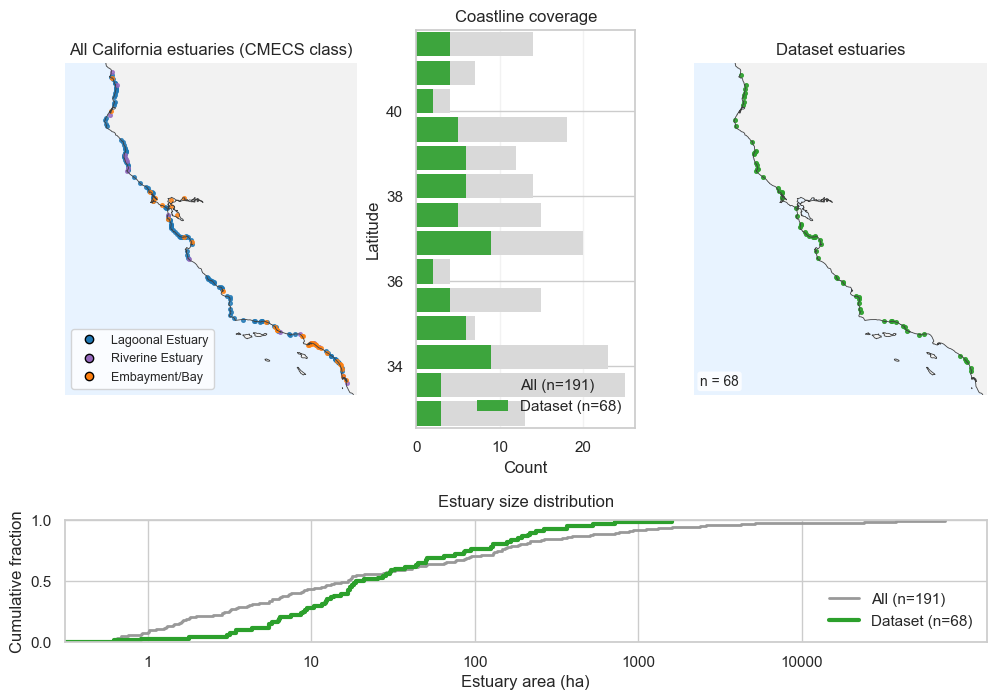

In [185]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.lines import Line2D


def make_opening_figure(joined):
    # --- prep ---
    df = joined.copy()
    df = df[df.geometry.notna()].copy()
    df["in_dataset"] = df["in_dataset"].fillna(False).astype(bool)
    df["CMECS_Class"] = df["CMECS_Class"].fillna("Unknown")

    # Use lagoonal-only for histogram+ECDF if desired:
    # df_lag = df[df["CMECS_Class"] == "Lagoonal Estuary"].copy()
    df_lag = df

    sns.set_theme(style="whitegrid")

    classes = ["Lagoonal Estuary", "Riverine Estuary", "Embayment/Bay", "Unknown"]
    classes = [c for c in classes if (df["CMECS_Class"] == c).any()]

    palette = {
        "Lagoonal Estuary": "#1f77b4",  # blue
        "Riverine Estuary": "#9467bd",  # purple
        "Embayment/Bay": "#ff7f0e",  # orange
        "Unknown": "0.6",
    }

    COLOR_ALL = "0.6"
    COLOR_DS = "#2ca02c"

    # --- layout you requested ---
    fig = plt.figure(figsize=(9.6, 7.2))

    gs = fig.add_gridspec(
        nrows=3,
        ncols=3,
        height_ratios=[1.0, 1.0, 0.8],  # bottom shorter (ECDF)
        width_ratios=[1.0, 0.75, 1.0],  # middle column a bit narrower
        wspace=0.22,
        hspace=0.65,
    )

    proj = ccrs.PlateCarree()

    # Top row: each spans rows 0:2 (2x1 "units")
    ax_map_all = fig.add_subplot(gs[0:2, 0], projection=proj)
    ax_cov = fig.add_subplot(gs[0:2, 1])
    ax_map_ds = fig.add_subplot(gs[0:2, 2], projection=proj)

    # Bottom: ECDF spans full width
    ax_ecdf = fig.add_subplot(gs[2, :])

    # Common CA extent
    minx, maxx = -125.6, -116.8
    miny, maxy = 32.2, 42.2
    MAP_POINT_SIZE = 7

    def setup_map_ax(ax, title):
        ax.set_extent([minx, maxx, miny, maxy], crs=proj)
        ax.add_feature(cfeature.LAND.with_scale("10m"), facecolor="0.95", edgecolor="none")
        ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="white", edgecolor="none")
        ax.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=0.6, color="0.25")
        ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="#e8f3ff", edgecolor="none")
        ax.axis("off")
        ax.set_title(title, fontsize=12)

    # ----------------
    # Panel A: All estuaries state map (colored by CMECS)
    # ----------------
    setup_map_ax(ax_map_all, "All California estuaries (CMECS class)")

    for cls in classes:
        g = df[df["CMECS_Class"] == cls]
        if g.empty:
            continue
        ax_map_all.scatter(
            g.geometry.x,
            g.geometry.y,
            s=MAP_POINT_SIZE,
            color=palette.get(cls, "0.6"),
            alpha=0.8,
            transform=proj,
            rasterized=True,
        )

    handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=palette.get(cls, "0.6"),
            markersize=6,
            label=cls,
        )
        for cls in classes
    ]
    ax_map_all.legend(handles=handles, loc="lower left", frameon=True, fontsize=9)

    # ----------------
    # Panel B: Coastline coverage (latitude histogram)
    # ----------------
    df_lag = df_lag[df_lag.geometry.notna()].copy()
    df_lag["lat"] = df_lag.geometry.y

    lat_all = df_lag["lat"].to_numpy()
    lat_ds = df_lag.loc[df_lag["in_dataset"], "lat"].to_numpy()

    n_bins = 14
    bins = np.linspace(lat_all.min(), lat_all.max(), n_bins + 1)

    counts_all, _ = np.histogram(lat_all, bins=bins)
    counts_ds, _ = np.histogram(lat_ds, bins=bins)

    bin_mids = 0.5 * (bins[:-1] + bins[1:])
    bin_h = (bins[1] - bins[0]) * 0.85

    ax_cov.barh(
        bin_mids,
        counts_all,
        height=bin_h,
        color="0.85",
        edgecolor="none",
        label=f"All (n={len(lat_all)})",
    )
    ax_cov.barh(
        bin_mids,
        counts_ds,
        height=bin_h,
        color=COLOR_DS,
        edgecolor="none",
        alpha=0.9,
        label=f"Dataset (n={len(lat_ds)})",
    )

    ax_cov.set_ylabel("Latitude")
    ax_cov.set_xlabel("Count")
    ax_cov.set_title("Coastline coverage", fontsize=12)
    ax_cov.set_ylim(lat_all.min(), lat_all.max())
    ax_cov.grid(axis="x", alpha=0.25)
    ax_cov.legend(loc="lower right", frameon=False)

    # ----------------
    # Panel C: Dataset-only state map (colored by CMECS)
    # ----------------
    ds = df[df["in_dataset"]].copy()
    setup_map_ax(ax_map_ds, "Dataset estuaries")

    ax_map_ds.scatter(
        ds.geometry.x,
        ds.geometry.y,
        s=MAP_POINT_SIZE,
        color=COLOR_DS,
        alpha=0.9,
        transform=proj,
        rasterized=True,
    )

    # Optional: tiny n label inside (avoids legend clutter)
    ax_map_ds.text(
        0.02,
        0.02,
        f"n = {len(ds)}",
        transform=ax_map_ds.transAxes,
        fontsize=10,
        ha="left",
        va="bottom",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8),
    )

    # ----------------
    # Panel D: ECDF size (ALL vs DATASET)
    # ----------------
    df_ecdf = df_lag[df_lag["Estuary_Hectares"].notna()].copy()

    sns.ecdfplot(
        data=df_ecdf,
        x="Estuary_Hectares",
        ax=ax_ecdf,
        color=COLOR_ALL,
        lw=2,
        label=f"All (n={len(df_ecdf)})",
    )
    sns.ecdfplot(
        data=df_ecdf[df_ecdf["in_dataset"]],
        x="Estuary_Hectares",
        ax=ax_ecdf,
        color=COLOR_DS,
        lw=3,
        label=f"Dataset (n={df_ecdf['in_dataset'].sum()})",
    )

    ax_ecdf.set_xscale("log")
    ax_ecdf.set_xlabel("Estuary area (ha)")
    ax_ecdf.set_ylabel("Cumulative fraction")
    ax_ecdf.set_title("Estuary size distribution", fontsize=12, pad=10)

    ticks = [1, 10, 100, 1000, 10000]
    ax_ecdf.set_xticks(ticks)
    ax_ecdf.set_xticklabels([str(t) for t in ticks])
    ax_ecdf.legend(loc="lower right", frameon=False)

    fig.subplots_adjust(left=0.03, right=0.99, top=0.95, bottom=0.10)
    return fig


# Usage:
fig = make_opening_figure(joined)
plt.savefig(SAVE_DIR / "dataset_ca_coverage_v2.png", dpi=300, bbox_inches="tight")
plt.show()

/Users/kyledorman/Documents/UCLA_kelp/estuary/.venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


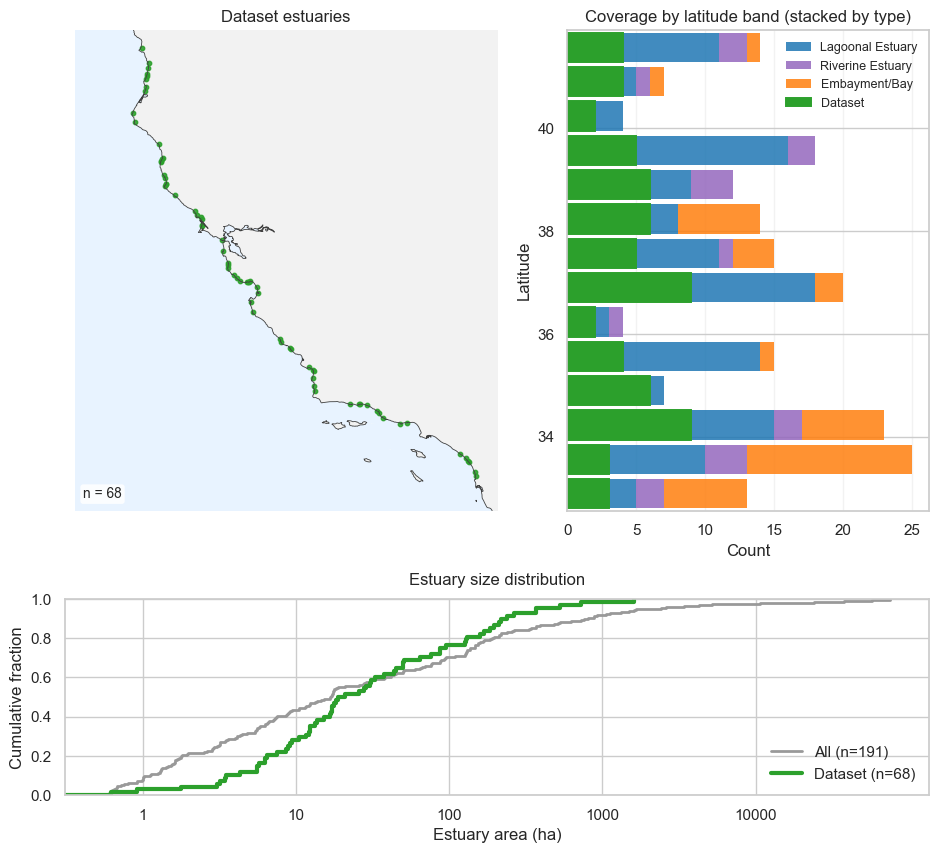

In [202]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


def make_opening_figure_v3(joined):
    df = joined.copy()
    df = df[df.geometry.notna()].copy()
    df["in_dataset"] = df["in_dataset"].fillna(False).astype(bool)
    df["CMECS_Class"] = df["CMECS_Class"].fillna("Unknown")

    sns.set_theme(style="whitegrid")

    # Classes to show (keep legend manageable)
    classes = ["Lagoonal Estuary", "Riverine Estuary", "Embayment/Bay", "Unknown"]
    classes = [c for c in classes if (df["CMECS_Class"] == c).any()]

    palette = {
        "Lagoonal Estuary": "#1f77b4",  # blue
        "Riverine Estuary": "#9467bd",  # purple
        "Embayment/Bay": "#ff7f0e",  # orange
        "Unknown": "0.6",
    }

    COLOR_DS = "#2ca02c"
    COLOR_ALL = "0.6"

    fig = plt.figure(figsize=(9, 9))
    gs = fig.add_gridspec(
        nrows=3,
        ncols=2,
        height_ratios=[1.0, 1.0, 1.0],
        width_ratios=[1.1, 0.9],
        wspace=0.15,
        hspace=0.45,
    )

    proj = ccrs.PlateCarree()
    ax_map = fig.add_subplot(gs[0:2, 0], projection=proj)
    ax_cov = fig.add_subplot(gs[0:2, 1])
    ax_ecdf = fig.add_subplot(gs[2, :])

    # Common CA extent
    minx, maxx = -125.6, -116.8
    miny, maxy = 32.2, 42.2

    # ---------- Panel A: Dataset-only map ----------
    ax_map.set_extent([minx, maxx, miny, maxy], crs=proj)
    ax_map.add_feature(cfeature.LAND.with_scale("10m"), facecolor="0.95", edgecolor="none")
    ax_map.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="#e8f3ff", edgecolor="none")
    ax_map.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=0.6, color="0.25")
    ax_map.axis("off")
    ax_map.set_title("Dataset estuaries", fontsize=12)

    ds = df[df["in_dataset"]]
    ax_map.scatter(
        ds.geometry.x,
        ds.geometry.y,
        s=10,
        color=COLOR_DS,
        alpha=0.9,
        transform=proj,
        rasterized=True,
    )
    ax_map.text(
        0.02,
        0.02,
        f"n = {len(ds)}",
        transform=ax_map.transAxes,
        fontsize=10,
        ha="left",
        va="bottom",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85),
    )

    # ---------- Panel B: Coverage histogram, stacked by CMECS ----------
    df["lat"] = df.geometry.y
    lat_all = df["lat"].to_numpy()

    n_bins = 14
    bins = np.linspace(lat_all.min(), lat_all.max(), n_bins + 1)
    bin_mids = 0.5 * (bins[:-1] + bins[1:])
    bin_h = (bins[1] - bins[0]) * 0.85

    # Build stacked counts by class
    bottom = np.zeros(n_bins, dtype=float)
    for cls in classes:
        g = df[df["CMECS_Class"] == cls]
        counts, _ = np.histogram(g["lat"].to_numpy(), bins=bins)
        ax_cov.barh(
            bin_mids,
            counts,
            height=bin_h,
            left=bottom,
            color=palette.get(cls, "0.6"),
            edgecolor="none",
            alpha=0.85,
            label=cls,
        )
        bottom += counts

    # Optional: overlay dataset counts as outline (so selection is visible)
    lat_ds = df.loc[df["in_dataset"], "lat"].to_numpy()
    ds_counts, _ = np.histogram(lat_ds, bins=bins)
    ax_cov.barh(
        bin_mids,
        ds_counts,
        height=bin_h,
        left=0,
        facecolor=COLOR_DS,
        edgecolor=COLOR_DS,
        linewidth=1.4,
        label="Dataset",
    )

    ax_cov.set_ylabel("Latitude")
    ax_cov.set_xlabel("Count")
    ax_cov.set_title("Coverage by latitude band (stacked by type)", fontsize=12)
    ax_cov.set_ylim(lat_all.min(), lat_all.max())
    ax_cov.grid(axis="x", alpha=0.25)

    # Legend inside (avoid spacing blow-up)
    ax_cov.legend(loc="upper right", frameon=False, fontsize=9)

    # ---------- Panel C: ECDF size (all vs dataset) ----------
    df_ecdf = df[df["Estuary_Hectares"].notna()].copy()

    sns.ecdfplot(
        data=df_ecdf,
        x="Estuary_Hectares",
        ax=ax_ecdf,
        color=COLOR_ALL,
        lw=2,
        label=f"All (n={len(df_ecdf)})",
    )
    sns.ecdfplot(
        data=df_ecdf[df_ecdf["in_dataset"]],
        x="Estuary_Hectares",
        ax=ax_ecdf,
        color=COLOR_DS,
        lw=3,
        label=f"Dataset (n={df_ecdf['in_dataset'].sum()})",
    )

    ax_ecdf.set_xscale("log")
    ax_ecdf.set_xlabel("Estuary area (ha)")
    ax_ecdf.set_ylabel("Cumulative fraction")
    ax_ecdf.set_title("Estuary size distribution", fontsize=12, pad=10)

    ticks = [1, 10, 100, 1000, 10000]
    ax_ecdf.set_xticks(ticks)
    ax_ecdf.set_xticklabels([str(t) for t in ticks])
    ax_ecdf.legend(loc="lower right", frameon=False)

    fig.subplots_adjust(left=0.03, right=0.99, top=0.95, bottom=0.10)
    return fig


# Usage:
fig = make_opening_figure_v3(joined)
plt.savefig(SAVE_DIR / "dataset_ca_coverage_v3.png", dpi=300, bbox_inches="tight")
plt.show()